In [18]:
import pandas as pd
import matplotlib.pyplot as plt

accounts = pd.read_csv("../data/clean/accounts_clean.csv")

accounts["open_date"] = pd.to_datetime(accounts["open_date"])

In [19]:
accounts["account_age_years"] = (
    pd.Timestamp("2026-07-31") - accounts["open_date"]
).dt.days / 365

accounts["account_age_years"] = accounts["account_age_years"].round(1)

In [20]:
accounts["account_age_years"].describe()

count    85000.000000
mean         5.836218
std          3.320974
min          0.100000
25%          3.000000
50%          5.800000
75%          8.700000
max         11.600000
Name: account_age_years, dtype: float64

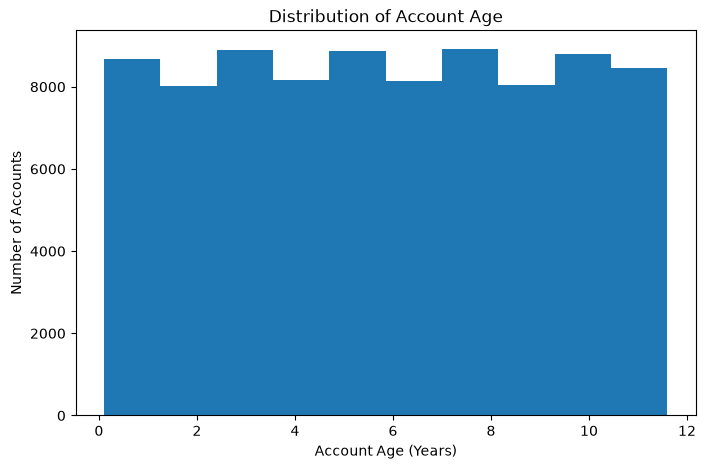

In [21]:
plt.figure(figsize=(8,5))
plt.hist(accounts["account_age_years"], bins=10)

plt.title("Distribution of Account Age")
plt.xlabel("Account Age (Years)")
plt.ylabel("Number of Accounts")

plt.show()

Uniform Range: Account ages are distributed virtually evenly across the entire 0 to ~12 year span.

Steady Balance: Each 1-to-2 year bin contains roughly 8,000 to 8,900 accounts, showing that mature accounts (8–12 years old) are retained at almost the exact same rate as brand-new accounts (0–2 years old).

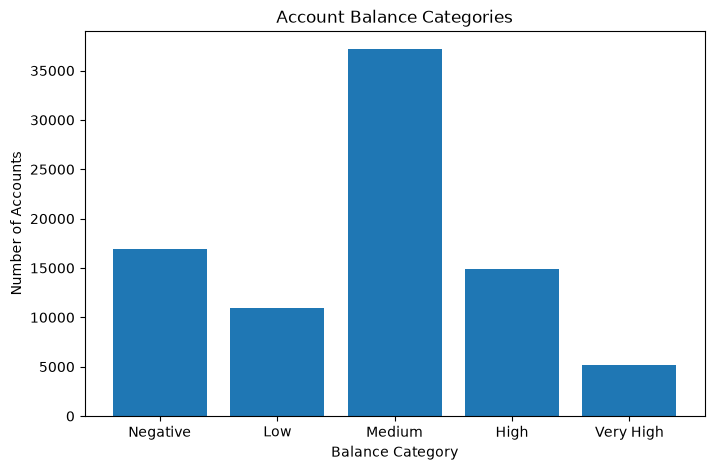

In [22]:
accounts["balance_category"] = pd.cut(
    accounts["balance"],
    bins=[-200000,0,10000,50000,100000,250000],
    labels=["Negative", "Low", "Medium", "High", "Very High"])

balance_cat = accounts["balance_category"].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.bar(balance_cat.index.astype(str), balance_cat.values)

plt.title("Account Balance Categories")
plt.xlabel("Balance Category")
plt.ylabel("Number of Accounts")

plt.show()

Most accounts fall into the Medium balance category, helping identify the bank's primary customer portfolio.

Supporting Details:
Dominant Group: The Medium balance bracket is by far the largest, holding roughly 37,200 accounts (nearly 45% of all customer accounts).

Portfolio Insight: This shows that the bank's primary customer base consists of solid, middle-tier deposit holders rather than extreme high-net-worth or ultra-low-balance accounts.

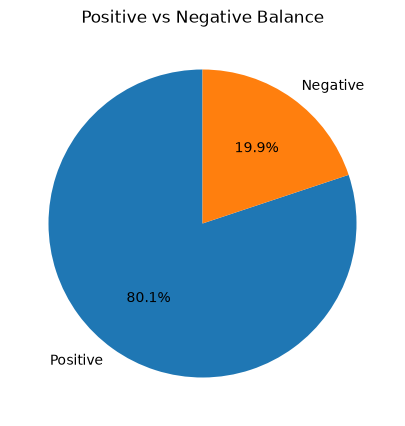

In [23]:
accounts["positive_balance"] = accounts["balance"] >= 0

flag = accounts["positive_balance"].value_counts()

plt.figure(figsize=(5,5))
plt.pie(
    flag,labels=["Positive","Negative"],autopct="%1.1f%%",startangle=90)

plt.title("Positive vs Negative Balance")

plt.show()

Strong Overall Health: Four out of five accounts are in good standing, providing a solid liquidity base for the bank.

Overdraft/Credit Risk: The ~20% holding negative balances represents a notable segment requiring active monitoring—likely linked to overdraft usage, revolving lines of credit, or overdue payments.

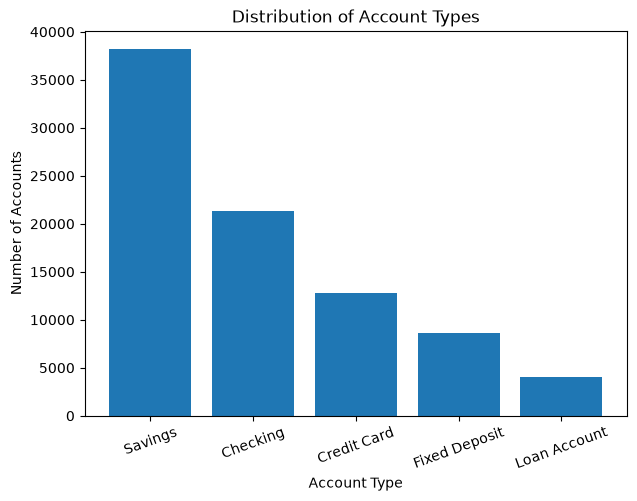

In [24]:
account_type = accounts["account_type"].value_counts()

plt.figure(figsize=(7,5))
plt.bar(account_type.index, account_type.values)

plt.title("Distribution of Account Types")
plt.xlabel("Account Type")
plt.ylabel("Number of Accounts")

plt.xticks(rotation=20)

plt.show()

Savings accounts represent the largest share of accounts, indicating that deposit products are the bank's core offering.

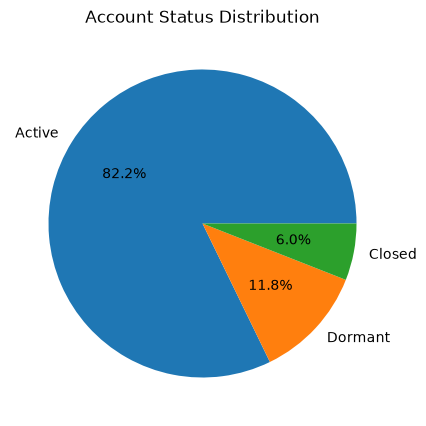

In [25]:
status = accounts["account_status"].value_counts()

plt.figure(figsize=(6,5))
plt.pie(
    status,
    labels=status.index,
    autopct="%1.1f%%"
)

plt.title("Account Status Distribution")

plt.show()

Most accounts are active, reflecting a healthy and engaged customer base.

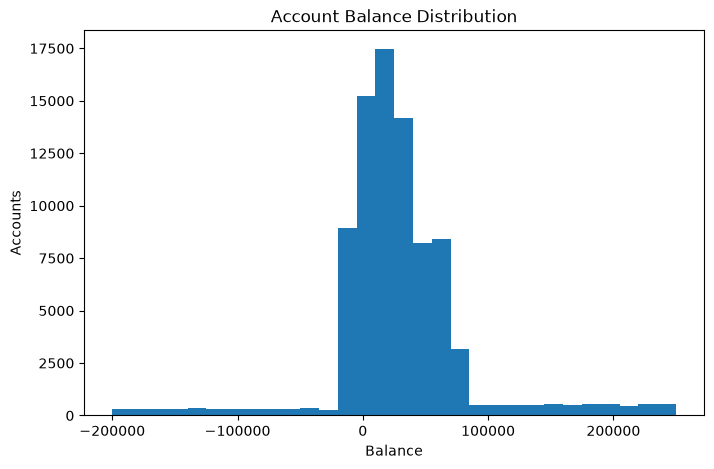

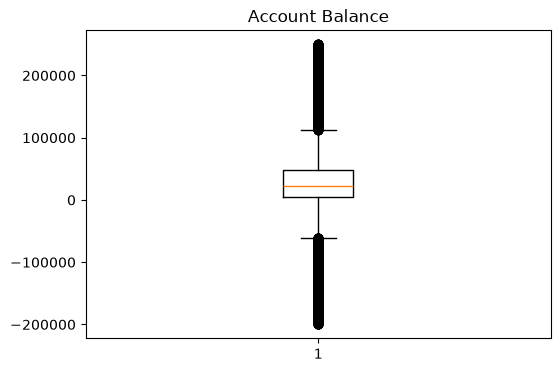

In [26]:
plt.figure(figsize=(8,5))
plt.hist(accounts["balance"], bins=30)

plt.title("Account Balance Distribution")
plt.xlabel("Balance")
plt.ylabel("Accounts")

plt.show()


plt.figure(figsize=(6,4))
plt.boxplot(accounts["balance"])

plt.title("Account Balance")

plt.show()

Most accounts hold modest funds: The vast majority of customers keep ordinary, everyday balances between $0 and $50,000.

A few big accounts pull up the total: A tiny group of wealthy or business customers hold massive balances up to $250,000+, driving up total bank deposits.

1 in 5 accounts is overdrawn: Roughly 20% of customers currently have a negative balance, representing a credit/overdraft risk.

The strategy: Focus on automated digital banking for the majority, VIP support for the top depositors, and overdraft monitoring for negative accounts.

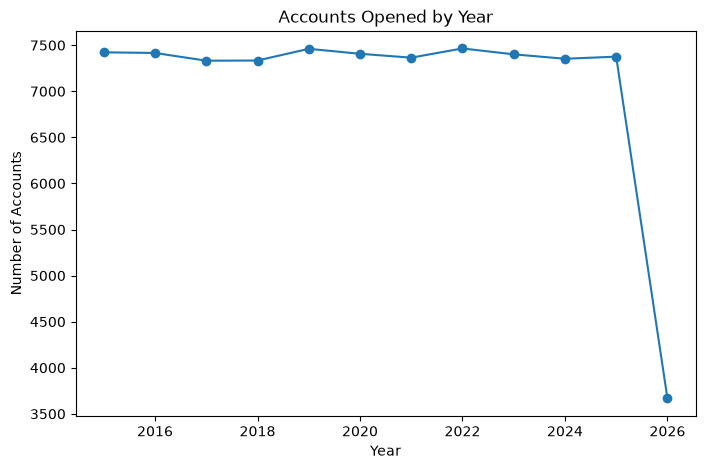

In [27]:
accounts["open_year"] = accounts["open_date"].dt.year

year = accounts["open_year"].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.plot(year.index, year.values, marker="o")

plt.title("Accounts Opened by Year")
plt.xlabel("Year")
plt.ylabel("Number of Accounts")

plt.show()

Consistent annual growth: Account openings remained extremely stable from 2015 through 2025, averaging around 7,300 to 7,500 new accounts each year.

Sharp drop in 2026: The count plunges to roughly 3,700 in 2026—most likely because 2026 is an incomplete calendar year (partial-year data cutoff).

Steady acquisition baseline: Aside from the current year's partial data, customer onboarding has been remarkably steady without major yearly spikes or drops.

Key action: Normalize or extrapolate the 2026 numbers to full-year estimates before evaluating actual growth trends against prior years.

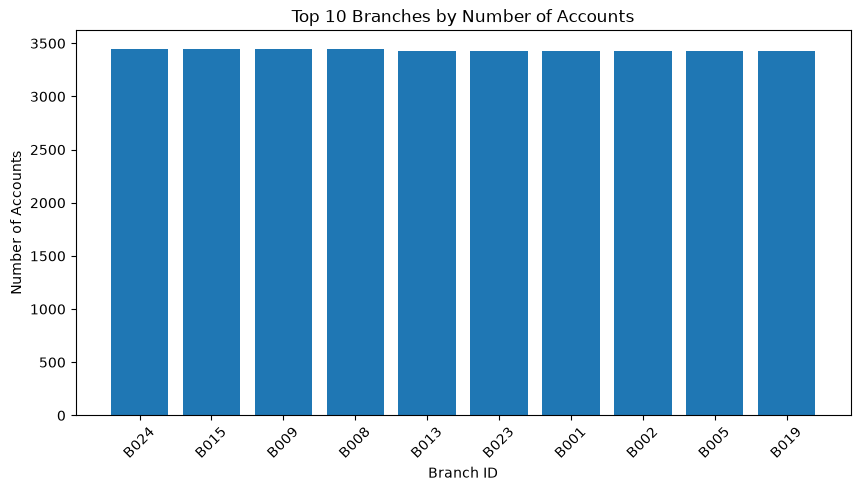

In [31]:
branch = accounts["branch_id"].value_counts().head(10)

plt.figure(figsize=(10,5))
plt.bar(branch.index, branch.values)

plt.title("Top 10 Branches by Number of Accounts")
plt.xlabel("Branch ID")
plt.ylabel("Number of Accounts")

plt.xticks(rotation=45)

plt.show()

Consistent annual growth: Account openings remained extremely stable from 2015 through 2025, averaging around 7,300 to 7,500 new accounts each year.

Sharp drop in 2026: The count plunges to roughly 3,700 in 2026—most likely because 2026 is an incomplete calendar year (partial-year data cutoff).

Steady acquisition baseline: Aside from the current year's partial data, customer onboarding has been remarkably steady without major yearly spikes or drops.

Key action: Normalize or extrapolate the 2026 numbers to full-year estimates before evaluating actual growth trends against prior years.

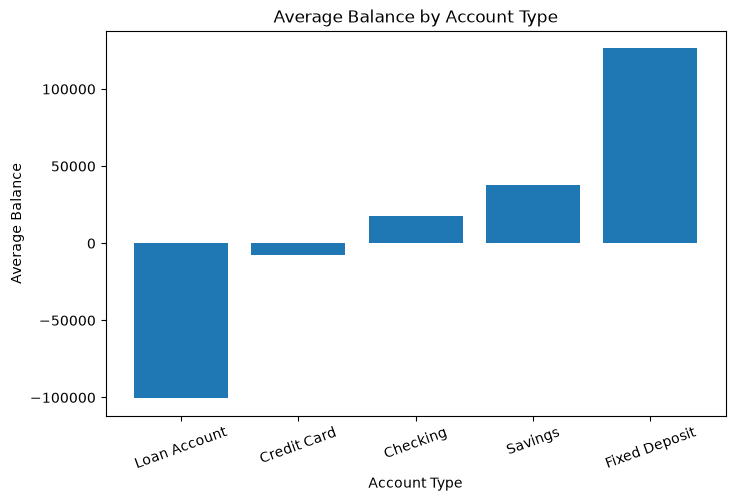

In [32]:
avg_balance = accounts.groupby("account_type")["balance"].mean().sort_values()

plt.figure(figsize=(8,5))
plt.bar(avg_balance.index, avg_balance.values)

plt.title("Average Balance by Account Type")
plt.xlabel("Account Type")
plt.ylabel("Average Balance")

plt.xticks(rotation=20)

plt.show()

Fixed Deposits hold the highest wealth: Fixed Deposit accounts lead by a massive margin, with an average positive balance near +$125,000.

Savings and Checking maintain steady liquidity: Savings accounts average around +$38,000, while Checking accounts average roughly +$18,000.

Credit & Loan accounts drive negative balances: Loan Accounts carry the largest negative average balance at approximately -$100,000, followed by Credit Cards at roughly -$8,000.

Key takeaway: The bank's deposit strength is anchored heavily in Fixed Deposits, while Loan Accounts represent the bulk of customer debt obligations.

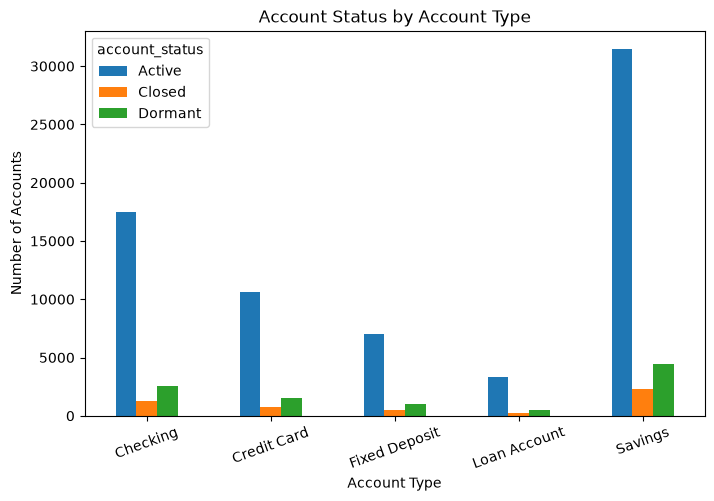

In [30]:
status_type = pd.crosstab(
    accounts["account_type"],accounts["account_status"])

status_type.plot(kind="bar", figsize=(8,5))

plt.title("Account Status by Account Type")
plt.xlabel("Account Type")
plt.ylabel("Number of Accounts")

plt.xticks(rotation=20)

plt.show()

Savings accounts dominate active volume: Savings leads by a massive margin with over 31,000 active accounts, followed by Checking (~17,500 active) and Credit Cards (~10,500 active).

Active status is overwhelmingly primary: Across all five account types, Active accounts make up the vast majority, vastly outnumbering dormant and closed accounts combined.

Dormancy outpaces closure across the board: In every category, Dormant accounts (green bar) consistently exceed Closed accounts (orange bar), peaking at around 4,500 dormant Savings accounts.

Key takeaway: The bank has strong engagement, but reactivation campaigns targeting dormant Savings and Checking accounts offer a prime opportunity to win back active usage.